In [57]:
    import pandas as pd
    import numpy as np
        
    df = pd.read_csv("../data/AB_NYC_2019.csv")

    df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [58]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
df.info()

Shape: (48895, 16)

Columns:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Data types:
<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  flo

In [59]:
print(
    "Missing reviews_per_month where number_of_reviews = 0:",
    ((df["reviews_per_month"].isna()) & (df["number_of_reviews"] == 0)).sum()
)

print(
    "Missing reviews_per_month where number_of_reviews > 0:",
    ((df["reviews_per_month"].isna()) & (df["number_of_reviews"] > 0)).sum()
)

print(
    "Missing last_review where number_of_reviews = 0:",
    ((df["last_review"].isna()) & (df["number_of_reviews"] == 0)).sum()
)

print(
    "Missing last_review where number_of_reviews > 0:",
    ((df["last_review"].isna()) & (df["number_of_reviews"] > 0)).sum()
)

Missing reviews_per_month where number_of_reviews = 0: 10052
Missing reviews_per_month where number_of_reviews > 0: 0
Missing last_review where number_of_reviews = 0: 10052
Missing last_review where number_of_reviews > 0: 0


In [60]:
df["price"].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [61]:
print("Zero-price listings:", (df["price"] == 0).sum())
print("Negative-price listings:", (df["price"] < 0).sum())

Zero-price listings: 11
Negative-price listings: 0


In [62]:
print(
    df["price"].quantile(
        [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1.00]
    )
)

0.000        0.0
0.010       30.0
0.050       40.0
0.250       69.0
0.500      106.0
0.750      175.0
0.900      269.0
0.950      355.0
0.990      799.0
0.995     1000.0
1.000    10000.0
Name: price, dtype: float64


In [63]:
df.nlargest(20, "price")[[
    "name",
    "neighbourhood_group",
    "neighbourhood",
    "room_type",
    "price",
    "minimum_nights"
]]

,name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights
9151,Furnished room in Astoria apartment,Queens,Astoria,Private room,10000,100
17692,Luxury 1 bedroom apt. -stunning Manhattan views,Brooklyn,Greenpoint,Entire home/apt,10000,5
29238,1-BR Lincoln Center,Manhattan,Upper West Side,Entire home/apt,10000,30
6530,Spanish Harlem Apt,Manhattan,East Harlem,Entire home/apt,9999,5
12342,"Quiet, Clean, Lit @ LES & Chinatown",Manhattan,Lower East Side,Private room,9999,99
40433,2br - The Heart of NYC: Manhattans Lower East ...,Manhattan,Lower East Side,Entire home/apt,9999,30
30268,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,Manhattan,Tribeca,Entire home/apt,8500,30
4377,Film Location,Brooklyn,Clinton Hill,Entire home/apt,8000,1
29662,East 72nd Townhouse by (Hidden by Airbnb),Manhattan,Upper East Side,Entire home/apt,7703,1
42523,70' Luxury MotorYacht on the Hudson,Manhattan,Battery Park City,Entire home/apt,7500,1


In [64]:
thresholds = [500, 750, 1000, 1500, 2000, 5000, 10000]

for t in thresholds:
    count = (df["price"] > t).sum()
    percentage = count / len(df) * 100
    print(f"Price > ${t}: {count} listings ({percentage:.3f}%)")

Price > $500: 1044 listings (2.135%)
Price > $750: 508 listings (1.039%)
Price > $1000: 239 listings (0.489%)
Price > $1500: 139 listings (0.284%)
Price > $2000: 86 listings (0.176%)
Price > $5000: 20 listings (0.041%)
Price > $10000: 0 listings (0.000%)


In [65]:
df = df[df["price"] > 0].copy()

In [66]:
print("Exactly $10,000:", (df["price"] == 10000).sum())
print("Price >= $5,000:", (df["price"] >= 5000).sum())
print("Price >= $2,000:", (df["price"] >= 2000).sum())
print("Price >= $1,000:", (df["price"] >= 1000).sum())

Exactly $10,000: 3
Price >= $5,000: 26
Price >= $2,000: 110
Price >= $1,000: 298


In [67]:
numeric_cols = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,48884.0,40.728953,0.054532,40.49979,40.69010,40.723080,40.76312,40.91306
longitude,48884.0,-73.952176,0.046159,-74.24442,-73.98308,-73.955685,-73.93629,-73.71299
minimum_nights,48884.0,7.029887,20.512224,1.00000,1.00000,3.000000,5.00000,1250.00000
number_of_reviews,48884.0,23.271991,44.551331,0.00000,1.00000,5.000000,24.00000,629.00000
reviews_per_month,38833.0,1.373128,1.680391,0.01000,0.19000,0.720000,2.02000,58.50000
calculated_host_listings_count,48884.0,7.144628,32.956185,1.00000,1.00000,1.000000,2.00000,327.00000
availability_365,48884.0,112.779498,131.627271,0.00000,0.00000,45.000000,227.00000,365.00000


In [68]:
categorical_cols = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(col)
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(20))


neighbourhood_group
Unique values: 5
neighbourhood_group
Manhattan        21660
Brooklyn         20095
Queens            5666
Bronx             1090
Staten Island      373
Name: count, dtype: int64

neighbourhood
Unique values: 221
neighbourhood
Williamsburg          3919
Bedford-Stuyvesant    3710
Harlem                2658
Bushwick              2462
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
East Harlem           1117
Greenpoint            1114
Chelsea               1113
Lower East Side        911
Astoria                900
Washington Heights     899
West Village           768
Financial District     744
Flatbush               621
Clinton Hill           572
Name: count, dtype: int64

room_type
Unique values: 3
room_type
Entire home/apt    25407
Private room       22319
Shared room         1158
Name: count, dtype: int64


In [69]:
cols = [
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count"
]

for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    
    print(f"\n{col}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"IQR upper bound: {upper}")
    print(f"Values above upper bound: {(df[col] > upper).sum()}")


minimum_nights
Q1: 1.0
Q3: 5.0
IQR: 4.0
IQR upper bound: 11.0
Values above upper bound: 6605

number_of_reviews
Q1: 1.0
Q3: 24.0
IQR: 23.0
IQR upper bound: 58.5
Values above upper bound: 6018

reviews_per_month
Q1: 0.19
Q3: 2.02
IQR: 1.83
IQR upper bound: 4.765000000000001
Values above upper bound: 1793

calculated_host_listings_count
Q1: 1.0
Q3: 2.0
IQR: 1.0
IQR upper bound: 3.5
Values above upper bound: 7073


In [70]:
print(
    df["minimum_nights"].quantile(
        [0.90, 0.95, 0.99, 0.995, 1.00]
    )
)
print("Minimum nights > 30:", (df["minimum_nights"] > 30).sum())
print("Minimum nights > 90:", (df["minimum_nights"] > 90).sum())
print("Minimum nights > 180:", (df["minimum_nights"] > 180).sum())
print("Minimum nights > 365:", (df["minimum_nights"] > 365).sum())

0.900      28.0
0.950      30.0
0.990      45.0
0.995      90.0
1.000    1250.0
Name: minimum_nights, dtype: float64
Minimum nights > 30: 747
Minimum nights > 90: 197
Minimum nights > 180: 81
Minimum nights > 365: 14


In [71]:
room_price = (
    df.groupby("room_type")["price"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("median", ascending=False)
)

room_price

,count,mean,median,min,max
room_type,,,,,
Entire home/apt,25407,211.810918,160.0,10,10000
Private room,22319,89.809131,70.0,10,10000
Shared room,1158,70.248705,45.0,10,1800


In [72]:
borough_price = (
    df.groupby("neighbourhood_group")["price"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("median", ascending=False)
)

borough_price

,count,mean,median,min,max
neighbourhood_group,,,,,
Manhattan,21660,196.884903,150.0,10,10000
Brooklyn,20095,124.438915,90.0,10,10000
Queens,5666,99.517649,75.0,10,10000
Staten Island,373,114.812332,75.0,13,5000
Bronx,1090,87.577064,65.0,10,2500


In [73]:
numeric_cols = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "price"
]

df[numeric_cols].corr()["price"].sort_values(ascending=False)

price                             1.000000
availability_365                  0.081847
calculated_host_listings_count    0.057462
minimum_nights                    0.042805
latitude                          0.033899
reviews_per_month                -0.030575
number_of_reviews                -0.047926
longitude                        -0.149954
Name: price, dtype: float64

In [74]:
neighbourhood_price = (
    df.groupby("neighbourhood")["price"]
    .agg(["count", "mean", "median"])
)

neighbourhood_price = (
    neighbourhood_price[neighbourhood_price["count"] >= 50]
    .sort_values("median", ascending=False)
)

neighbourhood_price.head(20)

,count,mean,median
neighbourhood,,,
Tribeca,177,490.638418,295.0
NoHo,78,295.717949,250.0
Flatiron District,80,341.925000,225.0
Midtown,1545,282.719094,210.0
Financial District,744,225.490591,200.0
West Village,768,267.682292,200.0
SoHo,358,287.103352,199.0
Chelsea,1113,249.738544,199.0
Greenwich Village,392,263.405612,197.5


In [75]:
neighbourhood_price.sort_values("median").head(20)

,count,mean,median
neighbourhood,,,
Corona,64,59.171875,40.0
Woodhaven,88,67.170455,52.0
Borough Park,136,63.066176,53.5
Elmhurst,237,80.459916,59.0
Fordham,63,69.444444,60.0
Woodside,235,85.097872,60.0
Ridgewood,423,77.184397,60.0
East Elmhurst,185,81.183784,60.0
Wakefield,50,85.580000,60.0


In [76]:
price_stats = df["price"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

price_stats

count    48884.000000
mean       152.755053
std        240.170260
min         10.000000
1%          30.000000
5%          40.000000
10%         49.000000
25%         69.000000
50%        106.000000
75%        175.000000
90%        269.000000
95%        355.000000
99%        799.000000
max      10000.000000
Name: price, dtype: float64

In [77]:
df["price"].skew()

np.float64(19.119026764709606)

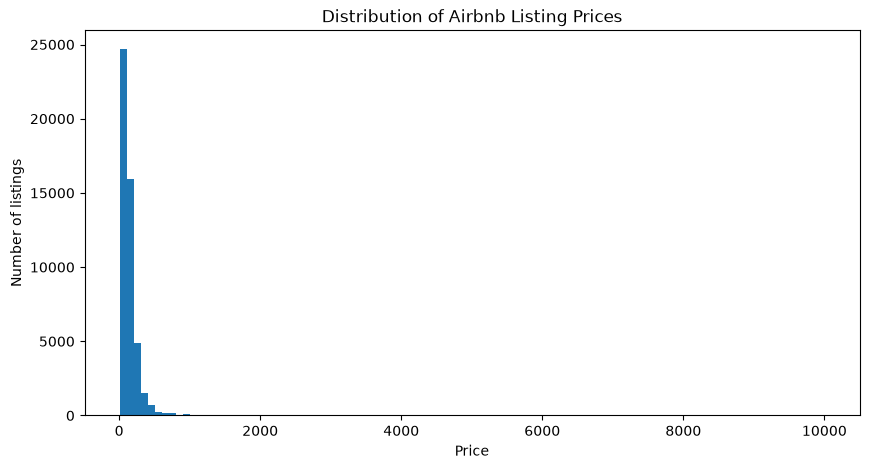

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df["price"], bins=100)
plt.xlabel("Price")
plt.ylabel("Number of listings")
plt.title("Distribution of Airbnb Listing Prices")
plt.show()

In [79]:
import numpy as np

log_price = np.log1p(df["price"])

print("Original skewness:", df["price"].skew())
print("Log-transformed skewness:", log_price.skew())

Original skewness: 19.119026764709606
Log-transformed skewness: 0.6294448333542177


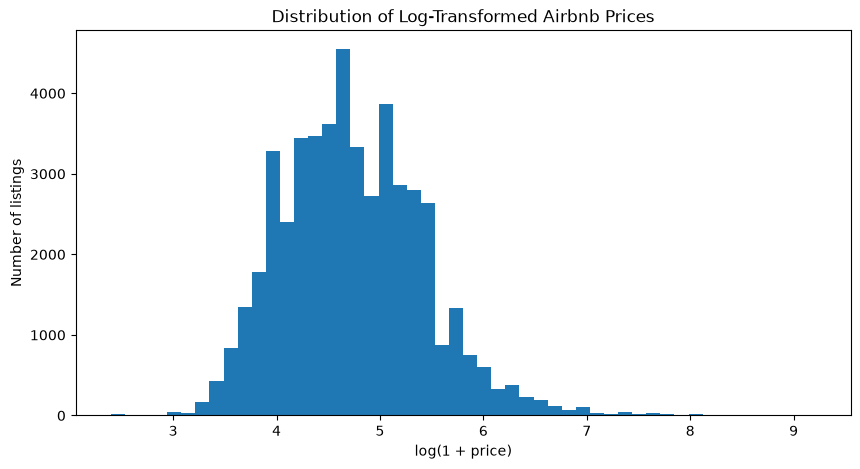

In [80]:
plt.figure(figsize=(10, 5))
plt.hist(np.log1p(df["price"]), bins=50)
plt.xlabel("log(1 + price)")
plt.ylabel("Number of listings")
plt.title("Distribution of Log-Transformed Airbnb Prices")
plt.show()

In [81]:
df["minimum_nights"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99, 0.995]
)

count    48884.000000
mean         7.029887
std         20.512224
min          1.000000
50%          3.000000
75%          5.000000
90%         28.000000
95%         30.000000
99%         45.000000
99.5%       90.000000
max       1250.000000
Name: minimum_nights, dtype: float64

In [82]:
df["minimum_nights"].skew()

np.float64(21.826796623888963)

In [83]:
df.groupby("minimum_nights")["price"].agg(
    ["count", "mean", "median"]
).head(20)

,count,mean,median
minimum_nights,,,
1,12717,142.056381,90.0
2,11693,146.307705,110.0
3,7998,160.271318,122.0
4,3302,161.240460,125.0
5,3033,157.362677,120.0
6,752,170.417553,120.0
7,2058,141.192906,100.0
8,130,119.484615,99.5
9,80,121.487500,109.5


In [84]:
df[df["minimum_nights"] > 30][
    ["minimum_nights", "price", "room_type", "neighbourhood_group", "neighbourhood"]
].sort_values("minimum_nights", ascending=False).head(20)

,minimum_nights,price,room_type,neighbourhood_group,neighbourhood
5767,1250,180,Entire home/apt,Manhattan,Greenwich Village
2854,1000,400,Entire home/apt,Manhattan,Battery Park City
13404,999,99,Entire home/apt,Manhattan,Harlem
26341,999,79,Private room,Brooklyn,Williamsburg
38664,999,110,Shared room,Manhattan,Greenwich Village
8014,500,75,Entire home/apt,Manhattan,Harlem
14285,500,45,Private room,Brooklyn,Kensington
11193,500,50,Private room,Brooklyn,Crown Heights
47620,500,140,Entire home/apt,Brooklyn,Williamsburg
7355,500,134,Entire home/apt,Queens,Long Island City


In [85]:
thresholds = [30, 60, 90, 180, 365, 500, 1000]

for t in thresholds:
    print(f"minimum_nights > {t}: {(df['minimum_nights'] > t).sum()}")

minimum_nights > 30: 747
minimum_nights > 60: 332
minimum_nights > 90: 197
minimum_nights > 180: 81
minimum_nights > 365: 14
minimum_nights > 500: 5
minimum_nights > 1000: 1


In [86]:
df["number_of_reviews"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99, 0.995]
)

count    48884.000000
mean        23.271991
std         44.551331
min          0.000000
50%          5.000000
75%         24.000000
90%         70.000000
95%        114.000000
99%        214.000000
99.5%      256.585000
max        629.000000
Name: number_of_reviews, dtype: float64

In [87]:
df["number_of_reviews"].skew()

np.float64(3.6912006647833877)

In [88]:
df["review_count_group"] = pd.cut(
    df["number_of_reviews"],
    bins=[-1, 0, 5, 10, 25, 50, 100, 200, 1000],
    labels=[
        "0", "1-5", "6-10", "11-25",
        "26-50", "51-100", "101-200", "200+"
    ]
)

df.groupby("review_count_group", observed=True)["price"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
review_count_group,,,
0,10051,192.938215,120.0
1-5,14837,148.539462,101.0
6-10,5430,149.695396,110.0
11-25,6953,140.394506,101.0
26-50,4658,137.288751,100.0
51-100,3960,130.572727,100.0
101-200,2360,129.847034,107.0
200+,635,113.651969,99.0


In [89]:
df.drop(columns=["review_count_group"], inplace=True)

In [90]:
df["reviews_per_month"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99, 0.995]
)

count    38833.000000
mean         1.373128
std          1.680391
min          0.010000
50%          0.720000
75%          2.020000
90%          3.630000
95%          4.640000
99%          7.196800
99.5%        8.425200
max         58.500000
Name: reviews_per_month, dtype: float64

In [91]:
df.loc[
    df["reviews_per_month"].isna(),
    "number_of_reviews"
].value_counts().head(10)

number_of_reviews
0    10051
Name: count, dtype: int64

In [92]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [93]:
print("Skewness of reviews_per_month:", df["reviews_per_month"].skew())

Skewness of reviews_per_month: 3.3016014291931928


In [94]:
df["review_rate_group"] = pd.cut(
    df["reviews_per_month"],
    bins=[-0.001, 0, 0.5, 1, 2, 4, 8, 100],
    labels=[
        "0", "0-0.5", "0.5-1", "1-2",
        "2-4", "4-8", "8+"
    ]
)

df.groupby("review_rate_group", observed=True)["price"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
review_rate_group,,,
0,10051,192.938215,120.0
0-0.5,16750,146.592657,109.0
0.5-1,6179,146.741382,105.0
1-2,6143,139.001140,100.0
2-4,6777,138.205401,100.0
4-8,2751,128.597237,98.0
8+,233,92.879828,69.0


In [95]:
df.drop(columns=["review_rate_group"], inplace=True)

In [96]:
df["calculated_host_listings_count"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99, 0.995]
)

count    48884.000000
mean         7.144628
std         32.956185
min          1.000000
50%          1.000000
75%          2.000000
90%          5.000000
95%         15.000000
99%        232.000000
99.5%      327.000000
max        327.000000
Name: calculated_host_listings_count, dtype: float64

In [97]:
df["calculated_host_listings_count"].skew()

np.float64(7.932252886661008)

In [98]:
df["host_listing_group"] = pd.cut(
    df["calculated_host_listings_count"],
    bins=[0, 1, 2, 5, 10, 25, 50, 100, 200, 400],
    labels=[
        "1", "2", "3-5", "6-10", "11-25",
        "26-50", "51-100", "101-200", "200+"
    ]
)

df.groupby("host_listing_group", observed=True)["price"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
host_listing_group,,,
1,32301,158.687502,119.0
2,6657,127.818988,90.0
3-5,5135,121.348004,79.0
6-10,1824,124.060307,75.0
11-25,902,237.786031,130.0
26-50,743,176.265141,139.0
51-100,539,193.961039,180.0
101-200,224,170.066964,137.5
200+,559,273.928444,252.0


In [99]:
df.drop(columns=["host_listing_group"], inplace=True)

In [100]:
df["availability_365"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99, 0.995]
)

count    48884.000000
mean       112.779498
std        131.627271
min          0.000000
50%         45.000000
75%        227.000000
90%        337.000000
95%        359.000000
99%        365.000000
99.5%      365.000000
max        365.000000
Name: availability_365, dtype: float64

In [101]:
df["availability_group"] = pd.cut(
    df["availability_365"],
    bins=[-1, 0, 30, 90, 180, 270, 364, 365],
    labels=[
        "0", "1-30", "31-90", "91-180",
        "181-270", "271-364", "365"
    ]
)

df.groupby("availability_group", observed=True)["price"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
availability_group,,,
0,17530,136.055391,100.0
1-30,5273,138.695809,110.0
31-90,6438,145.088692,100.0
91-180,5282,161.527641,110.0
181-270,4511,173.492352,125.0
271-364,8555,170.221274,119.0
365,1295,250.769884,125.0


In [102]:
df.drop(columns=["availability_group"], inplace=True)

In [103]:
df[["latitude", "longitude"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

,latitude,longitude
count,48884.000000,48884.000000
mean,40.728953,-73.952176
std,0.054532,0.046159
min,40.499790,-74.244420
1%,40.596682,-74.026801
5%,40.646103,-74.003880
25%,40.690100,-73.983080
50%,40.723080,-73.955685
75%,40.763120,-73.936290
95%,40.825638,-73.865755


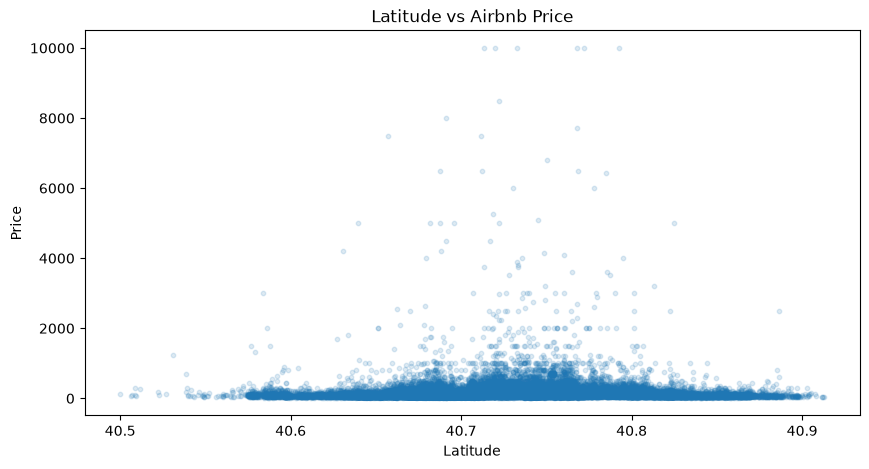

In [104]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["latitude"],
    df["price"],
    alpha=0.15,
    s=10
)

plt.xlabel("Latitude")
plt.ylabel("Price")
plt.title("Latitude vs Airbnb Price")
plt.show()

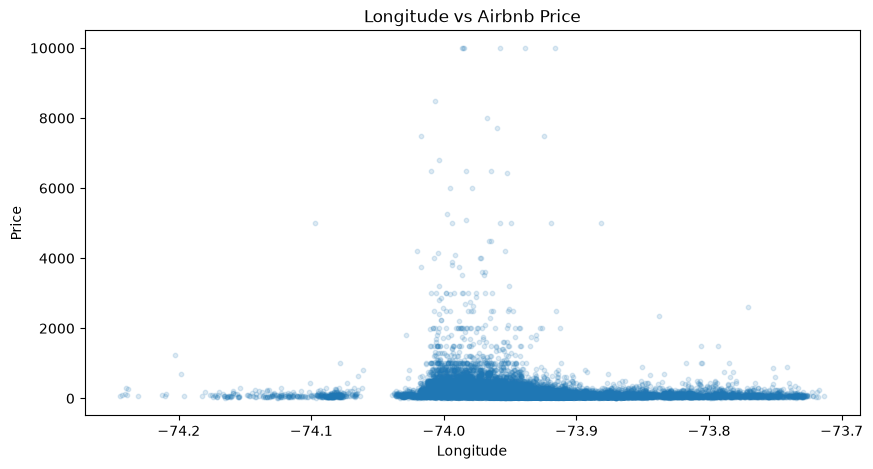

In [105]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["longitude"],
    df["price"],
    alpha=0.15,
    s=10
)

plt.xlabel("Longitude")
plt.ylabel("Price")
plt.title("Longitude vs Airbnb Price")
plt.show()

In [106]:
df[["latitude", "longitude"]].corr()

,latitude,longitude
latitude,1.00000,0.08483
longitude,0.08483,1.00000


In [107]:
df.columns.tolist()

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [108]:
print("Data type:", df["last_review"].dtype)
print("Missing values:", df["last_review"].isna().sum())
print("Unique dates:", df["last_review"].nunique())
print("Earliest review:", df["last_review"].min())
print("Latest review:", df["last_review"].max())

Data type: str
Missing values: 10051
Unique dates: 1764
Earliest review: 2011-03-28
Latest review: 2019-07-08


In [109]:
review_year = pd.to_datetime(
    df["last_review"],
    errors="coerce"
).dt.year

review_year.value_counts().sort_index()

last_review
2011.0        7
2012.0       25
2013.0       48
2014.0      199
2015.0     1393
2016.0     2707
2017.0     3204
2018.0     6048
2019.0    25202
Name: count, dtype: int64

In [110]:
df = df.drop(columns=["has_review", "review_year"])

df.columns.tolist()

KeyError: "['has_review', 'review_year'] not found in axis"

In [ ]:
df["has_review"] = df["last_review"].notna().astype(int)

df.groupby("has_review")["price"].agg(
    ["count", "mean", "median"]
)

In [ ]:
(df["has_review"] == (df["number_of_reviews"] > 0).astype(int)).all()

In [ ]:
df = df.drop(columns=["has_review", "review_year"])

df.columns.tolist()

In [ ]:
for col in ["name", "host_name", "neighbourhood_group", "neighbourhood", "room_type"]:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique())
    print("Missing:", df[col].isna().sum())

In [ ]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate listing IDs:", df["id"].duplicated().sum())
print("Duplicate host IDs:", df["host_id"].duplicated().sum())

In [ ]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing

In [ ]:
df.groupby(["neighbourhood_group", "room_type"])["price"].agg(
    ["count", "mean", "median"]
).round(2)

In [ ]:
checks = {
    "latitude <= 0": (df["latitude"] <= 0).sum(),
    "longitude >= 0": (df["longitude"] >= 0).sum(),
    "minimum_nights <= 0": (df["minimum_nights"] <= 0).sum(),
    "number_of_reviews < 0": (df["number_of_reviews"] < 0).sum(),
    "reviews_per_month < 0": (df["reviews_per_month"] < 0).sum(),
    "calculated_host_listings_count < 1": (df["calculated_host_listings_count"] < 1).sum(),
    "availability_365 < 0": (df["availability_365"] < 0).sum(),
    "availability_365 > 365": (df["availability_365"] > 365).sum()
}

pd.Series(checks)

In [ ]:
df[
    [
        "minimum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "calculated_host_listings_count",
        "availability_365"
    ]
].quantile([0.90, 0.95, 0.99, 0.995, 1.00]).T

In [ ]:
df[
    [
        "latitude",
        "longitude",
        "minimum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "calculated_host_listings_count",
        "availability_365",
        "price"
    ]
].corr().round(3)

In [ ]:
df.groupby("room_type")["price"].agg(
    ["count", "mean", "std", "median", "min", "max"]
).round(2)

In [ ]:
neighbourhood_counts = df["neighbourhood"].value_counts()

print("Neighbourhoods with < 5 listings:", (neighbourhood_counts < 5).sum())
print("Neighbourhoods with < 10 listings:", (neighbourhood_counts < 10).sum())
print("Neighbourhoods with < 20 listings:", (neighbourhood_counts < 20).sum())
print("Minimum listings in a neighbourhood:", neighbourhood_counts.min())

In [ ]:
neighbourhood_price_stats = df.groupby("neighbourhood")["price"].agg(
    ["count", "median", "mean"]
).sort_values("median", ascending=False)

neighbourhood_price_stats.head(15)

In [ ]:
neighbourhood_price_stats.sort_values("median").head(15)

In [ ]:
from collections import Counter
import re

text = " ".join(df["name"].dropna().astype(str).str.lower())

words = re.findall(r"\b[a-z]{3,}\b", text)
word_counts = Counter(words)

word_counts.most_common(30)

In [ ]:
name_stats = df["name"].fillna("").astype(str).str.split().str.len()

name_stats.describe().round(2)

In [ ]:
features = [
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

X = df[features].copy()
y = df["price"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

numerical_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train processed shape:", X_train_processed.shape)
print("X_test processed shape :", X_test_processed.shape)

In [ ]:
for feature, categories in zip(
    categorical_features,
    preprocessor.named_transformers_["cat"].categories_
):
    print(f"{feature}: {len(categories)} categories")

In [ ]:
train_neighbourhoods = set(X_train["neighbourhood"].unique())
test_neighbourhoods = set(X_test["neighbourhood"].unique())

sorted(test_neighbourhoods - train_neighbourhoods)

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)

print("Linear Regression trained successfully.")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_train_pred = linear_model.predict(X_train_processed)
y_test_pred = linear_model.predict(X_test_processed)

print("Training:")
print("MAE :", mean_absolute_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R²  :", r2_score(y_train, y_train_pred))

print("\nTest:")
print("MAE :", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R²  :", r2_score(y_test, y_test_pred))

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_processed, y_train)

y_train_ridge = ridge_model.predict(X_train_processed)
y_test_ridge = ridge_model.predict(X_test_processed)

print("Training:")
print("MAE :", mean_absolute_error(y_train, y_train_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_ridge)))
print("R²  :", r2_score(y_train, y_train_ridge))

print("\nTest:")
print("MAE :", mean_absolute_error(y_test, y_test_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_ridge)))
print("R²  :", r2_score(y_test, y_test_ridge))

In [ ]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("Original target:")
print(y_train.describe())

print("\nLog-transformed target:")
print(y_train_log.describe())

In [ ]:
linear_log_model = LinearRegression()
linear_log_model.fit(X_train_processed, y_train_log)

y_train_log_pred = linear_log_model.predict(X_train_processed)
y_test_log_pred = linear_log_model.predict(X_test_processed)

# Convert predictions back to original price scale
y_train_log_pred_price = np.expm1(y_train_log_pred)
y_test_log_pred_price = np.expm1(y_test_log_pred)

print("Training:")
print("MAE :", mean_absolute_error(y_train, y_train_log_pred_price))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_log_pred_price)))
print("R²  :", r2_score(y_train, y_train_log_pred_price))

print("\nTest:")
print("MAE :", mean_absolute_error(y_test, y_test_log_pred_price))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_log_pred_price)))
print("R²  :", r2_score(y_test, y_test_log_pred_price))

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest trained successfully.")

In [ ]:
y_train_rf = rf_model.predict(X_train_processed)
y_test_rf = rf_model.predict(X_test_processed)

print("Training:")
print("MAE :", mean_absolute_error(y_train, y_train_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_rf)))
print("R²  :", r2_score(y_train, y_train_rf))

print("\nTest:")
print("MAE :", mean_absolute_error(y_test, y_test_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_rf)))
print("R²  :", r2_score(y_test, y_test_rf))

In [ ]:
rf_regularized = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_regularized.fit(X_train_processed, y_train)

print("Regularized Random Forest trained successfully.")

In [ ]:
y_train_rf_reg = rf_regularized.predict(X_train_processed)
y_test_rf_reg = rf_regularized.predict(X_test_processed)

print("Training:")
print("MAE :", mean_absolute_error(y_train, y_train_rf_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_rf_reg)))
print("R²  :", r2_score(y_train, y_train_rf_reg))

print("\nTest:")
print("MAE :", mean_absolute_error(y_test, y_test_rf_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_rf_reg)))
print("R²  :", r2_score(y_test, y_test_rf_reg))

In [ ]:
importance_df["original_feature"] = (
    importance_df["feature"]
    .str.replace(r"^(num|cat)__", "", regex=True)
    .str.split("_", n=1)
    .str[0]
)

importance_df["original_feature"] = importance_df["feature"].apply(
    lambda x: x.split("__", 1)[1].split("_", 1)[0]
    if "__" in x else x
)

grouped_importance = (
    importance_df
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

grouped_importance

In [ ]:
importance_df["original_feature"] = importance_df["feature"].apply(
    lambda x: next(
        (f for f in features if x.startswith(("num__" + f, "cat__" + f + "_"))),
        x
    )
)

grouped_importance = (
    importance_df
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

grouped_importance

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_processed, y_train)

print("Gradient Boosting trained successfully.")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_train_pred_gb = gb_model.predict(X_train_processed)
y_test_pred_gb = gb_model.predict(X_test_processed)

gb_results = {
    "Train MAE": mean_absolute_error(y_train, y_train_pred_gb),
    "Test MAE": mean_absolute_error(y_test, y_test_pred_gb),
    "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred_gb)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred_gb)),
    "Train R²": r2_score(y_train, y_train_pred_gb),
    "Test R²": r2_score(y_test, y_test_pred_gb)
}

gb_results

In [ ]:
gb_model_2 = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb_model_2.fit(X_train_processed, y_train)

y_train_pred_gb2 = gb_model_2.predict(X_train_processed)
y_test_pred_gb2 = gb_model_2.predict(X_test_processed)

gb2_results = {
    "Train MAE": mean_absolute_error(y_train, y_train_pred_gb2),
    "Test MAE": mean_absolute_error(y_test, y_test_pred_gb2),
    "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred_gb2)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred_gb2)),
    "Train R²": r2_score(y_train, y_train_pred_gb2),
    "Test R²": r2_score(y_test, y_test_pred_gb2)
}

gb2_results

In [ ]:
gb_model_3 = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

gb_model_3.fit(X_train_processed, y_train)

y_train_pred_gb3 = gb_model_3.predict(X_train_processed)
y_test_pred_gb3 = gb_model_3.predict(X_test_processed)

gb3_results = {
    "Train MAE": mean_absolute_error(y_train, y_train_pred_gb3),
    "Test MAE": mean_absolute_error(y_test, y_test_pred_gb3),
    "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred_gb3)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred_gb3)),
    "Train R²": r2_score(y_train, y_train_pred_gb3),
    "Test R²": r2_score(y_test, y_test_pred_gb3)
}

gb3_results

In [ ]:
gb_model_4 = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.10,
    max_depth=3,
    random_state=42
)

gb_model_4.fit(X_train_processed, y_train)

y_train_pred_gb4 = gb_model_4.predict(X_train_processed)
y_test_pred_gb4 = gb_model_4.predict(X_test_processed)

gb4_results = {
    "Train MAE": mean_absolute_error(y_train, y_train_pred_gb4),
    "Test MAE": mean_absolute_error(y_test, y_test_pred_gb4),
    "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred_gb4)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred_gb4)),
    "Train R²": r2_score(y_train, y_train_pred_gb4),
    "Test R²": r2_score(y_test, y_test_pred_gb4)
}

gb4_results

In [ ]:
import importlib.util

if importlib.util.find_spec("optuna") is None:
    print("Optuna is not installed.")
else:
    import optuna
    print("Optuna version:", optuna.__version__)

In [ ]:
%pip install optuna

In [ ]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

print("Optuna version:", optuna.__version__)
print("Training data:", X_train_processed.shape)
print("Target:", y_train.shape)

In [ ]:
def objective(trial):
    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=trial.suggest_int("max_depth", 8, 30),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        max_features=trial.suggest_float("max_features", 0.3, 1.0),
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X_train_processed,
        y_train,
        cv=3,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    return -scores.mean()


print("Optuna objective defined successfully.")

In [ ]:
study = optuna.create_study(
    direction="minimize",
    study_name="airbnb_rf_optimization"
)

study.optimize(
    objective,
    n_trials=20,
    show_progress_bar=True
)

print("\nBest CV MAE:", study.best_value)
print("Best parameters:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")

In [ ]:
best_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=study.best_params["max_depth"],
    min_samples_split=study.best_params["min_samples_split"],
    min_samples_leaf=study.best_params["min_samples_leaf"],
    max_features=study.best_params["max_features"],
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train_processed, y_train)

print("Optimized Random Forest trained successfully.")

In [ ]:
y_train_pred_best = best_rf.predict(X_train_processed)
y_test_pred_best = best_rf.predict(X_test_processed)

best_rf_results = {
    "Train MAE": mean_absolute_error(y_train, y_train_pred_best),
    "Test MAE": mean_absolute_error(y_test, y_test_pred_best),
    "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred_best)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred_best)),
    "Train R²": r2_score(y_train, y_train_pred_best),
    "Test R²": r2_score(y_test, y_test_pred_best)
}

best_rf_results

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor

extra_trees = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

extra_trees.fit(X_train_processed, y_train)

print("Extra Trees trained successfully.")

In [ ]:
y_train_pred_extra = extra_trees.predict(X_train_processed)
y_test_pred_extra = extra_trees.predict(X_test_processed)

extra_results = {
    "Train MAE": mean_absolute_error(y_train, y_train_pred_extra),
    "Test MAE": mean_absolute_error(y_test, y_test_pred_extra),
    "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred_extra)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred_extra)),
    "Train R²": r2_score(y_train, y_train_pred_extra),
    "Test R²": r2_score(y_test, y_test_pred_extra)
}

extra_results

In [ ]:
residuals = y_test - y_test_pred_best

residual_summary = pd.Series(residuals).describe()

print(residual_summary)
print("\nMean residual:", residuals.mean())
print("Median residual:", np.median(residuals))

In [ ]:
log_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=study.best_params["max_depth"],
    min_samples_split=study.best_params["min_samples_split"],
    min_samples_leaf=study.best_params["min_samples_leaf"],
    max_features=study.best_params["max_features"],
    random_state=42,
    n_jobs=-1
)

log_rf.fit(X_train_processed, np.log1p(y_train))

y_train_pred_log_rf = np.expm1(log_rf.predict(X_train_processed))
y_test_pred_log_rf = np.expm1(log_rf.predict(X_test_processed))

log_rf_results = {
    "Train MAE": mean_absolute_error(y_train, y_train_pred_log_rf),
    "Test MAE": mean_absolute_error(y_test, y_test_pred_log_rf),
    "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred_log_rf)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred_log_rf)),
    "Train R²": r2_score(y_train, y_train_pred_log_rf),
    "Test R²": r2_score(y_test, y_test_pred_log_rf)
}

log_rf_results

In [ ]:
error_analysis = pd.DataFrame({
    "actual_price": y_test,
    "predicted_price": y_test_pred_best
})

error_analysis["absolute_error"] = (
    error_analysis["actual_price"] - error_analysis["predicted_price"]
).abs()

error_analysis["price_range"] = pd.cut(
    error_analysis["actual_price"],
    bins=[0, 50, 100, 200, 500, 1000, 2000, np.inf],
    labels=["$10–50", "$51–100", "$101–200", "$201–500",
            "$501–1000", "$1001–2000", "$2000+"]
)

error_by_range = error_analysis.groupby(
    "price_range", observed=False
).agg(
    Count=("actual_price", "size"),
    Mean_Actual=("actual_price", "mean"),
    Mean_Predicted=("predicted_price", "mean"),
    MAE=("absolute_error", "mean")
)

error_by_range

In [ ]:
error_analysis["residual"] = (
    error_analysis["actual_price"] - error_analysis["predicted_price"]
)

bias_by_range = error_analysis.groupby(
    "price_range", observed=False
).agg(
    Count=("residual", "size"),
    Mean_Residual=("residual", "mean"),
    Median_Residual=("residual", "median")
)

bias_by_range

In [ ]:
expensive = df[df["price"] >= 500].copy()

expensive_summary = (
    expensive
    .groupby(["neighbourhood", "room_type"])
    .agg(
        Count=("price", "size"),
        Mean_Price=("price", "mean"),
        Median_Price=("price", "median")
    )
    .sort_values("Mean_Price", ascending=False)
)

expensive_summary.head(20)

In [ ]:
error_analysis["absolute_percentage_error"] = (
    error_analysis["absolute_error"] / error_analysis["actual_price"]
) * 100

percentage_error_by_range = (
    error_analysis
    .groupby("price_range", observed=False)
    .agg(
        Count=("actual_price", "size"),
        Mean_Absolute_Percentage_Error=("absolute_percentage_error", "mean")
    )
)

percentage_error_by_range

In [ ]:
manhattan_lat = 40.7580
manhattan_lon = -73.9855

distance_to_manhattan = np.sqrt(
    (df["latitude"] - manhattan_lat) ** 2 +
    (df["longitude"] - manhattan_lon) ** 2
)

distance_price = pd.DataFrame({
    "distance": distance_to_manhattan,
    "price": df["price"]
})

distance_price["distance_bin"] = pd.qcut(
    distance_price["distance"],
    q=10,
    duplicates="drop"
)

distance_price.groupby("distance_bin", observed=True)["price"].agg(
    ["count", "mean", "median"]
)

In [ ]:
X_geo = df[features].copy()

X_geo["distance_to_manhattan"] = np.sqrt(
    (X_geo["latitude"] - 40.7580) ** 2 +
    (X_geo["longitude"] + 73.9855) ** 2
)

X_train_geo, X_test_geo, y_train_geo, y_test_geo = train_test_split(
    X_geo,
    y,
    test_size=0.20,
    random_state=42
)

categorical_features_geo = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

numerical_features_geo = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "distance_to_manhattan"
]

preprocessor_geo = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_geo),
        ("num", "passthrough", numerical_features_geo)
    ]
)

X_train_geo_processed = preprocessor_geo.fit_transform(X_train_geo)
X_test_geo_processed = preprocessor_geo.transform(X_test_geo)

print("Training shape:", X_train_geo_processed.shape)
print("Test shape:", X_test_geo_processed.shape)

In [ ]:
geo_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=study.best_params["max_depth"],
    min_samples_split=study.best_params["min_samples_split"],
    min_samples_leaf=study.best_params["min_samples_leaf"],
    max_features=study.best_params["max_features"],
    random_state=42,
    n_jobs=-1
)

geo_rf.fit(X_train_geo_processed, y_train_geo)

y_train_pred_geo = geo_rf.predict(X_train_geo_processed)
y_test_pred_geo = geo_rf.predict(X_test_geo_processed)

geo_rf_results = {
    "Train MAE": mean_absolute_error(y_train_geo, y_train_pred_geo),
    "Test MAE": mean_absolute_error(y_test_geo, y_test_pred_geo),
    "Train RMSE": np.sqrt(mean_squared_error(y_train_geo, y_train_pred_geo)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test_geo, y_test_pred_geo)),
    "Train R²": r2_score(y_train_geo, y_train_pred_geo),
    "Test R²": r2_score(y_test_geo, y_test_pred_geo)
}

geo_rf_results

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

vif_df = df[vif_features].copy()

vif_results = pd.DataFrame({
    "Feature": vif_features,
    "VIF": [
        variance_inflation_factor(vif_df.values, i)
        for i in range(vif_df.shape[1])
    ]
})

vif_results.sort_values("VIF", ascending=False)

In [ ]:
price_distribution = pd.DataFrame({
    "Range": [
        "$10–50",
        "$51–100",
        "$101–200",
        "$201–500",
        "$501–1000",
        "$1001–2000",
        "$2000+"
    ],
    "Count": [
        ((y_train >= 10) & (y_train <= 50)).sum(),
        ((y_train >= 51) & (y_train <= 100)).sum(),
        ((y_train >= 101) & (y_train <= 200)).sum(),
        ((y_train >= 201) & (y_train <= 500)).sum(),
        ((y_train >= 501) & (y_train <= 1000)).sum(),
        ((y_train >= 1001) & (y_train <= 2000)).sum(),
        (y_train > 2000).sum()
    ]
})

price_distribution

In [ ]:
def objective_rmse(trial):
    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=trial.suggest_int("max_depth", 8, 40),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        max_features=trial.suggest_float("max_features", 0.2, 1.0),
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X_train_processed,
        y_train,
        cv=3,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    return -scores.mean()


study_rmse = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_rmse.optimize(objective_rmse, n_trials=50)

print("Best CV RMSE:", study_rmse.best_value)
print("Best parameters:")
print(study_rmse.best_params)

In [ ]:
rmse_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=study_rmse.best_params["max_depth"],
    min_samples_split=study_rmse.best_params["min_samples_split"],
    min_samples_leaf=study_rmse.best_params["min_samples_leaf"],
    max_features=study_rmse.best_params["max_features"],
    random_state=42,
    n_jobs=-1
)

rmse_rf.fit(X_train_processed, y_train)

y_train_pred_rmse_rf = rmse_rf.predict(X_train_processed)
y_test_pred_rmse_rf = rmse_rf.predict(X_test_processed)

rmse_rf_results = {
    "Train MAE": mean_absolute_error(y_train, y_train_pred_rmse_rf),
    "Test MAE": mean_absolute_error(y_test, y_test_pred_rmse_rf),
    "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred_rmse_rf)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred_rmse_rf)),
    "Train R²": r2_score(y_train, y_train_pred_rmse_rf),
    "Test R²": r2_score(y_test, y_test_pred_rmse_rf)
}

rmse_rf_results

In [ ]:
import importlib.util

print("XGBoost:", importlib.util.find_spec("xgboost") is not None)
print("LightGBM:", importlib.util.find_spec("lightgbm") is not None)
print("CatBoost:", importlib.util.find_spec("catboost") is not None)

In [ ]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_processed, y_train)

y_train_pred_xgb = xgb_model.predict(X_train_processed)
y_test_pred_xgb = xgb_model.predict(X_test_processed)

xgb_results = {
    "Train MAE": mean_absolute_error(y_train, y_train_pred_xgb),
    "Test MAE": mean_absolute_error(y_test, y_test_pred_xgb),
    "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred_xgb)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred_xgb)),
    "Train R²": r2_score(y_train, y_train_pred_xgb),
    "Test R²": r2_score(y_test, y_test_pred_xgb)
}

xgb_results

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_processed, y_train)

y_train_pred_xgb = xgb_model.predict(X_train_processed)
y_test_pred_xgb = xgb_model.predict(X_test_processed)

xgb_results = {
    "Train MAE": mean_absolute_error(y_train, y_train_pred_xgb),
    "Test MAE": mean_absolute_error(y_test, y_test_pred_xgb),
    "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred_xgb)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred_xgb)),
    "Train R²": r2_score(y_train, y_train_pred_xgb),
    "Test R²": r2_score(y_test, y_test_pred_xgb)
}

xgb_results

In [ ]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

def objective_xgb_rmse(trial):
    model = XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 200, 800),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        gamma=trial.suggest_float("gamma", 0, 5),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X_train_processed,
        y_train,
        cv=3,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    return -scores.mean()


study_xgb = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_xgb.optimize(
    objective_xgb_rmse,
    n_trials=50
)

print("Best CV RMSE:", study_xgb.best_value)
print("\nBest parameters:")
print(study_xgb.best_params)

In [ ]:
xgb_tuned = XGBRegressor(
    n_estimators=573,
    learning_rate=0.016350173712040374,
    max_depth=8,
    min_child_weight=8,
    subsample=0.7334723068671101,
    colsample_bytree=0.5863293983924752,
    gamma=1.0546120033224238,
    reg_alpha=0.023196031680889417,
    reg_lambda=9.396019995998323,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(X_train_processed, y_train)

y_train_pred_xgb_tuned = xgb_tuned.predict(X_train_processed)
y_test_pred_xgb_tuned = xgb_tuned.predict(X_test_processed)

xgb_tuned_results = {
    "Train MAE": mean_absolute_error(y_train, y_train_pred_xgb_tuned),
    "Test MAE": mean_absolute_error(y_test, y_test_pred_xgb_tuned),
    "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred_xgb_tuned)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred_xgb_tuned)),
    "Train R²": r2_score(y_train, y_train_pred_xgb_tuned),
    "Test R²": r2_score(y_test, y_test_pred_xgb_tuned)
}

xgb_tuned_results

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Copy listing names
name_train = df.loc[X_train.index, "name"].fillna("")
name_test = df.loc[X_test.index, "name"].fillna("")

# TF-IDF using words and bigrams
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_features=5000
)

name_train_tfidf = tfidf.fit_transform(name_train)
name_test_tfidf = tfidf.transform(name_test)

print("Training TF-IDF shape:", name_train_tfidf.shape)
print("Test TF-IDF shape:", name_test_tfidf.shape)

In [ ]:
from sklearn.model_selection import KFold
import pandas as pd
import numpy as np

# Categorical columns we want to target encode
target_encode_cols = [
    "neighbourhood",
    "neighbourhood_group",
    "room_type"
]

# Copy training/test data
X_train_te = X_train.copy()
X_test_te = X_test.copy()

# Overall training target mean
global_mean = y_train.mean()

# Out-of-fold encoder
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for col in target_encode_cols:
    X_train_te[col + "_te"] = np.nan

    for train_idx, val_idx in kf.split(X_train):
        X_fold = X_train.iloc[train_idx]
        y_fold = y_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]

        # Category means learned ONLY from the fold's training portion
        stats = pd.DataFrame({
            col: X_fold[col],
            "target": y_fold.values
        }).groupby(col)["target"].agg(["mean", "count"])

        # Smoothing to reduce overfitting for rare categories
        smoothing = 10

        smoothed_mean = (
            (stats["count"] * stats["mean"] + smoothing * global_mean)
            / (stats["count"] + smoothing)
        )

        X_train_te.loc[
            X_val.index,
            col + "_te"
        ] = X_val[col].map(smoothed_mean).fillna(global_mean)

    # Test set uses statistics from ALL training data only
    stats_full = pd.DataFrame({
        col: X_train[col],
        "target": y_train.values
    }).groupby(col)["target"].agg(["mean", "count"])

    smoothed_mean_full = (
        (stats_full["count"] * stats_full["mean"] + smoothing * global_mean)
        / (stats_full["count"] + smoothing)
    )

    X_test_te[col + "_te"] = (
        X_test[col]
        .map(smoothed_mean_full)
        .fillna(global_mean)
    )

print("Target encoding completed.")

print("\nEncoded training columns:")
print(X_train_te[[col + "_te" for col in target_encode_cols]].head())

print("\nEncoded test columns:")
print(X_test_te[[col + "_te" for col in target_encode_cols]].head())

In [ ]:
# Numerical features
numerical_features_te = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

# Target-encoded features
target_encoded_features = [
    "neighbourhood_te",
    "neighbourhood_group_te",
    "room_type_te"
]

# Final feature list
te_features = numerical_features_te + target_encoded_features

# Create training and test matrices
X_train_te_final = X_train_te[te_features].copy()
X_test_te_final = X_test_te[te_features].copy()

print("Training shape:", X_train_te_final.shape)
print("Test shape:", X_test_te_final.shape)

print("\nFeatures:")
print(te_features)

print("\nMissing values:")
print("Train:", X_train_te_final.isna().sum().sum())
print("Test:", X_test_te_final.isna().sum().sum())

In [ ]:
xgb_te = XGBRegressor(
    n_estimators=573,
    learning_rate=0.016350173712040374,
    max_depth=8,
    min_child_weight=8,
    subsample=0.7334723068671101,
    colsample_bytree=0.5863293983924752,
    gamma=1.0546120033224238,
    reg_alpha=0.023196031680889417,
    reg_lambda=9.396019995998323,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_te.fit(X_train_te_final, y_train)

y_train_pred_te = xgb_te.predict(X_train_te_final)
y_test_pred_te = xgb_te.predict(X_test_te_final)

xgb_te_results = {
    "Train MAE": mean_absolute_error(y_train, y_train_pred_te),
    "Test MAE": mean_absolute_error(y_test, y_test_pred_te),
    "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred_te)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred_te)),
    "Train R²": r2_score(y_train, y_train_pred_te),
    "Test R²": r2_score(y_test, y_test_pred_te)
}

xgb_te_results

In [ ]:
# Create neighbourhood × room type interaction
X_train_te["neighbourhood_room_type"] = (
    X_train_te["neighbourhood"].astype(str)
    + "__"
    + X_train_te["room_type"].astype(str)
)

X_test_te["neighbourhood_room_type"] = (
    X_test_te["neighbourhood"].astype(str)
    + "__"
    + X_test_te["room_type"].astype(str)
)

print("Unique training combinations:",
      X_train_te["neighbourhood_room_type"].nunique())

print("\nExample combinations:")
print(X_train_te["neighbourhood_room_type"].head())

In [ ]:
interaction_col = "neighbourhood_room_type"
encoded_col = "neighbourhood_room_type_te"

# Create empty column
X_train_te[encoded_col] = np.nan

# 5-fold out-of-fold encoding
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(X_train_te):
    X_fold = X_train_te.iloc[train_idx]
    y_fold = y_train.iloc[train_idx]
    X_val = X_train_te.iloc[val_idx]

    # Category statistics from fold-training data only
    stats = pd.DataFrame({
        interaction_col: X_fold[interaction_col],
        "target": y_fold.values
    }).groupby(interaction_col)["target"].agg(["mean", "count"])

    # Smoothing
    smoothing = 10

    smoothed_mean = (
        (stats["count"] * stats["mean"] + smoothing * global_mean)
        / (stats["count"] + smoothing)
    )

    # Encode validation fold
    X_train_te.loc[
        X_val.index,
        encoded_col
    ] = (
        X_val[interaction_col]
        .map(smoothed_mean)
        .fillna(global_mean)
    )

# Encode test set using ALL training data only
stats_full = pd.DataFrame({
    interaction_col: X_train_te[interaction_col],
    "target": y_train.values
}).groupby(interaction_col)["target"].agg(["mean", "count"])

smoothed_mean_full = (
    (stats_full["count"] * stats_full["mean"] + smoothing * global_mean)
    / (stats_full["count"] + smoothing)
)

X_test_te[encoded_col] = (
    X_test_te[interaction_col]
    .map(smoothed_mean_full)
    .fillna(global_mean)
)

print("Interaction target encoding completed.")

print("\nTraining:")
print(X_train_te[[interaction_col, encoded_col]].head())

print("\nTest:")
print(X_test_te[[interaction_col, encoded_col]].head())

print("\nMissing values:")
print("Train:", X_train_te[encoded_col].isna().sum())
print("Test:", X_test_te[encoded_col].isna().sum())

In [ ]:
# Add the neighbourhood × room_type target encoding
te_features_interaction = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "neighbourhood_te",
    "neighbourhood_group_te",
    "room_type_te",
    "neighbourhood_room_type_te"
]

X_train_te_interaction = X_train_te[te_features_interaction].copy()
X_test_te_interaction = X_test_te[te_features_interaction].copy()

print("Training shape:", X_train_te_interaction.shape)
print("Test shape:", X_test_te_interaction.shape)

print("\nMissing values:")
print("Train:", X_train_te_interaction.isna().sum().sum())
print("Test:", X_test_te_interaction.isna().sum().sum())

In [ ]:
xgb_te_interaction = XGBRegressor(
    n_estimators=573,
    learning_rate=0.016350173712040374,
    max_depth=8,
    min_child_weight=8,
    subsample=0.7334723068671101,
    colsample_bytree=0.5863293983924752,
    gamma=1.0546120033224238,
    reg_alpha=0.023196031680889417,
    reg_lambda=9.396019995998323,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_te_interaction.fit(
    X_train_te_interaction,
    y_train
)

y_train_pred_te_interaction = xgb_te_interaction.predict(
    X_train_te_interaction
)

y_test_pred_te_interaction = xgb_te_interaction.predict(
    X_test_te_interaction
)

xgb_te_interaction_results = {
    "Train MAE": mean_absolute_error(
        y_train, y_train_pred_te_interaction
    ),
    "Test MAE": mean_absolute_error(
        y_test, y_test_pred_te_interaction
    ),
    "Train RMSE": np.sqrt(
        mean_squared_error(y_train, y_train_pred_te_interaction)
    ),
    "Test RMSE": np.sqrt(
        mean_squared_error(y_test, y_test_pred_te_interaction)
    ),
    "Train R²": r2_score(
        y_train, y_train_pred_te_interaction
    ),
    "Test R²": r2_score(
        y_test, y_test_pred_te_interaction
    )
}

xgb_te_interaction_results

In [ ]:
# Log-transform the target
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Use the same tuned XGBoost hyperparameters
xgb_log = XGBRegressor(
    n_estimators=573,
    learning_rate=0.016350173712040374,
    max_depth=8,
    min_child_weight=8,
    subsample=0.7334723068671101,
    colsample_bytree=0.5863293983924752,
    gamma=1.0546120033224238,
    reg_alpha=0.023196031680889417,
    reg_lambda=9.396019995998323,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_log.fit(X_train_processed, y_train_log)

# Predictions are initially on log scale
y_train_pred_log = xgb_log.predict(X_train_processed)
y_test_pred_log = xgb_log.predict(X_test_processed)

# Convert predictions back to original price scale
y_train_pred_log_original = np.expm1(y_train_pred_log)
y_test_pred_log_original = np.expm1(y_test_pred_log)

# Evaluate on original dollar scale
xgb_log_results = {
    "Train MAE": mean_absolute_error(
        y_train, y_train_pred_log_original
    ),
    "Test MAE": mean_absolute_error(
        y_test, y_test_pred_log_original
    ),
    "Train RMSE": np.sqrt(
        mean_squared_error(y_train, y_train_pred_log_original)
    ),
    "Test RMSE": np.sqrt(
        mean_squared_error(y_test, y_test_pred_log_original)
    ),
    "Train R²": r2_score(
        y_train, y_train_pred_log_original
    ),
    "Test R²": r2_score(
        y_test, y_test_pred_log_original
    )
}

xgb_log_results

In [ ]:
# Compare errors of original-target and log-target XGBoost
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Original Target Prediction": y_test_pred_xgb_tuned,
    "Log Target Prediction": y_test_pred_log_original
})

comparison["Original Error"] = (
    comparison["Actual Price"]
    - comparison["Original Target Prediction"]
).abs()

comparison["Log Error"] = (
    comparison["Actual Price"]
    - comparison["Log Target Prediction"]
).abs()

comparison["Price Range"] = pd.cut(
    comparison["Actual Price"],
    bins=[0, 50, 100, 200, 500, 1000, 2000, np.inf],
    labels=[
        "$10–50",
        "$51–100",
        "$101–200",
        "$201–500",
        "$501–1000",
        "$1001–2000",
        "$2000+"
    ]
)

error_comparison = comparison.groupby(
    "Price Range",
    observed=True
).agg(
    Count=("Actual Price", "size"),
    Original_MAE=("Original Error", "mean"),
    Log_MAE=("Log Error", "mean")
)

error_comparison

In [ ]:
# Copy the original train/test feature sets
X_train_geo = X_train.copy()
X_test_geo = X_test.copy()

# Reference points
manhattan_lat = 40.7580
manhattan_lon = -73.9855

nyc_lat = 40.7128
nyc_lon = -74.0060

# Manhattan distance approximation
X_train_geo["distance_manhattan"] = np.sqrt(
    (X_train_geo["latitude"] - manhattan_lat) ** 2 +
    (X_train_geo["longitude"] - manhattan_lon) ** 2
)

X_test_geo["distance_manhattan"] = np.sqrt(
    (X_test_geo["latitude"] - manhattan_lat) ** 2 +
    (X_test_geo["longitude"] - manhattan_lon) ** 2
)

# Distance to NYC reference point
X_train_geo["distance_nyc_center"] = np.sqrt(
    (X_train_geo["latitude"] - nyc_lat) ** 2 +
    (X_train_geo["longitude"] - nyc_lon) ** 2
)

X_test_geo["distance_nyc_center"] = np.sqrt(
    (X_test_geo["latitude"] - nyc_lat) ** 2 +
    (X_test_geo["longitude"] - nyc_lon) ** 2
)

# Latitude/longitude interaction
X_train_geo["lat_lon_interaction"] = (
    X_train_geo["latitude"] * X_train_geo["longitude"]
)

X_test_geo["lat_lon_interaction"] = (
    X_test_geo["latitude"] * X_test_geo["longitude"]
)

# Squared geographic coordinates
X_train_geo["latitude_squared"] = X_train_geo["latitude"] ** 2
X_test_geo["latitude_squared"] = X_test_geo["latitude"] ** 2

X_train_geo["longitude_squared"] = X_train_geo["longitude"] ** 2
X_test_geo["longitude_squared"] = X_test_geo["longitude"] ** 2

print("Training shape:", X_train_geo.shape)
print("Test shape:", X_test_geo.shape)

print("\nNew features:")
print([
    "distance_manhattan",
    "distance_nyc_center",
    "lat_lon_interaction",
    "latitude_squared",
    "longitude_squared"
])

print("\nSample:")
print(
    X_train_geo[
        [
            "latitude",
            "longitude",
            "distance_manhattan",
            "distance_nyc_center",
            "lat_lon_interaction",
            "latitude_squared",
            "longitude_squared"
        ]
    ].head()
)

In [ ]:
categorical_features_geo = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

numerical_features_geo = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "distance_manhattan",
    "distance_nyc_center",
    "lat_lon_interaction",
    "latitude_squared",
    "longitude_squared"
]

preprocessor_geo = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_geo
        ),
        (
            "num",
            "passthrough",
            numerical_features_geo
        )
    ]
)

X_train_geo_processed = preprocessor_geo.fit_transform(X_train_geo)
X_test_geo_processed = preprocessor_geo.transform(X_test_geo)

print("Processed training shape:", X_train_geo_processed.shape)
print("Processed test shape:", X_test_geo_processed.shape)

In [ ]:
xgb_geo = XGBRegressor(
    n_estimators=573,
    learning_rate=0.016350173712040374,
    max_depth=8,
    min_child_weight=8,
    subsample=0.7334723068671101,
    colsample_bytree=0.5863293983924752,
    gamma=1.0546120033224238,
    reg_alpha=0.023196031680889417,
    reg_lambda=9.396019995998323,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_geo.fit(X_train_geo_processed, y_train)

y_train_pred_geo = xgb_geo.predict(X_train_geo_processed)
y_test_pred_geo = xgb_geo.predict(X_test_geo_processed)

xgb_geo_results = {
    "Train MAE": mean_absolute_error(
        y_train, y_train_pred_geo
    ),
    "Test MAE": mean_absolute_error(
        y_test, y_test_pred_geo
    ),
    "Train RMSE": np.sqrt(
        mean_squared_error(y_train, y_train_pred_geo)
    ),
    "Test RMSE": np.sqrt(
        mean_squared_error(y_test, y_test_pred_geo)
    ),
    "Train R²": r2_score(
        y_train, y_train_pred_geo
    ),
    "Test R²": r2_score(
        y_test, y_test_pred_geo
    )
}

xgb_geo_results

In [ ]:
cap = df["price"].quantile(0.99)
print("99th percentile price cap:", cap)
df["price_capped"] = df["price"].clip(upper=cap)

manhattan_lat, manhattan_lon = 40.7580, -73.9855
df["distance_to_manhattan"] = np.sqrt(
    (df["latitude"] - manhattan_lat) ** 2 + (df["longitude"] - manhattan_lon) ** 2
)

features = [
    "neighbourhood_group", "neighbourhood", "latitude", "longitude",
    "distance_to_manhattan", "room_type", "minimum_nights",
    "number_of_reviews", "reviews_per_month",
    "calculated_host_listings_count", "availability_365",
]

X = df[features].copy()
y = df["price_capped"].copy()
names = df["name"].fillna("").copy()

In [ ]:
X_train, X_test, y_train, y_test, name_train, name_test = train_test_split(
    X, y, names, test_size=0.20, random_state=42
)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [ ]:
train_enc = X_train.copy()
train_enc["log_price"] = y_train_log.values
neigh_target_mean = train_enc.groupby("neighbourhood")["log_price"].mean()
global_mean = y_train_log.mean()

X_train["neighbourhood_te"] = X_train["neighbourhood"].map(neigh_target_mean).fillna(global_mean)
X_test["neighbourhood_te"] = X_test["neighbourhood"].map(neigh_target_mean).fillna(global_mean)

X_train_final = X_train.drop(columns=["neighbourhood"])
X_test_final = X_test.drop(columns=["neighbourhood"])

In [ ]:
categorical_features = ["neighbourhood_group", "room_type"]
numerical_features = [
    "latitude", "longitude", "distance_to_manhattan", "neighbourhood_te",
    "minimum_nights", "number_of_reviews", "reviews_per_month",
    "calculated_host_listings_count", "availability_365",
]

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", "passthrough", numerical_features),
])

X_train_processed = preprocessor.fit_transform(X_train_final)
X_test_processed = preprocessor.transform(X_test_final)
print(X_train_processed.shape)

In [ ]:
from scipy.sparse import hstack, csr_matrix

tfidf = TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2), min_df=5, max_features=300)
name_train_tfidf = tfidf.fit_transform(name_train)
name_test_tfidf = tfidf.transform(name_test)

X_train_combined = hstack([csr_matrix(X_train_processed), name_train_tfidf]).tocsr()
X_test_combined = hstack([csr_matrix(X_test_processed), name_test_tfidf]).tocsr()
print(X_train_combined.shape)

In [ ]:
def evaluate(name, model, Xtr, Xte, feature_desc=""):
    model.fit(Xtr, y_train_log)
    pred_tr_price = np.expm1(model.predict(Xtr))
    pred_te_price = np.expm1(model.predict(Xte))
    return {
        "model": name, "features": feature_desc,
        "train_mae": mean_absolute_error(y_train, pred_tr_price),
        "test_mae": mean_absolute_error(y_test, pred_te_price),
        "train_rmse": np.sqrt(mean_squared_error(y_train, pred_tr_price)),
        "test_rmse": np.sqrt(mean_squared_error(y_test, pred_te_price)),
        "train_r2": r2_score(y_train, pred_tr_price),
        "test_r2": r2_score(y_test, pred_te_price),
    }

In [ ]:
results = []

rf = RandomForestRegressor(n_estimators=300, max_depth=18, min_samples_leaf=2, random_state=42, n_jobs=-1)
results.append(evaluate("RandomForest", rf, X_train_processed, X_test_processed, "structured only"))

rf2 = RandomForestRegressor(n_estimators=300, max_depth=18, min_samples_leaf=2, random_state=42, n_jobs=-1)
results.append(evaluate("RandomForest", rf2, X_train_combined, X_test_combined, "structured + TF-IDF"))

xgb = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6, subsample=0.8,
                    colsample_bytree=0.8, objective="reg:squarederror", random_state=42, n_jobs=-1)
results.append(evaluate("XGBoost", xgb, X_train_processed, X_test_processed, "structured only"))

xgb2 = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6, subsample=0.8,
                     colsample_bytree=0.8, objective="reg:squarederror", random_state=42, n_jobs=-1)
results.append(evaluate("XGBoost", xgb2, X_train_combined, X_test_combined, "structured + TF-IDF"))

pd.DataFrame(results).round(3)

In [ ]:
# Compare all models from the current experiment
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="test_r2",
    ascending=False
).reset_index(drop=True)

results_df.round(4)

In [ ]:
# Leakage-safe host-level features

# Create host statistics using TRAINING data only
train_host_stats = (
    pd.DataFrame({
        "host_id": df.loc[X_train.index, "host_id"],
        "price": y_train
    })
    .groupby("host_id")["price"]
    .agg(
        host_mean_price="mean",
        host_median_price="median",
        host_listing_count="count"
    )
)

# Global fallback values for hosts not present in training data
global_mean_price = y_train.mean()

# Map each feature separately
train_host_mean = df.loc[X_train.index, "host_id"].map(
    train_host_stats["host_mean_price"]
)

train_host_median = df.loc[X_train.index, "host_id"].map(
    train_host_stats["host_median_price"]
)

train_host_count = df.loc[X_train.index, "host_id"].map(
    train_host_stats["host_listing_count"]
)

test_host_mean = df.loc[X_test.index, "host_id"].map(
    train_host_stats["host_mean_price"]
)

test_host_median = df.loc[X_test.index, "host_id"].map(
    train_host_stats["host_median_price"]
)

test_host_count = df.loc[X_test.index, "host_id"].map(
    train_host_stats["host_listing_count"]
)

# Fill unseen hosts
train_host_mean = train_host_mean.fillna(global_mean_price)
train_host_median = train_host_median.fillna(global_mean_price)
train_host_count = train_host_count.fillna(0)

test_host_mean = test_host_mean.fillna(global_mean_price)
test_host_median = test_host_median.fillna(global_mean_price)
test_host_count = test_host_count.fillna(0)

# Combine into feature DataFrames
host_train = pd.DataFrame({
    "host_mean_price": train_host_mean,
    "host_median_price": train_host_median,
    "host_listing_count": train_host_count
})

host_test = pd.DataFrame({
    "host_mean_price": test_host_mean,
    "host_median_price": test_host_median,
    "host_listing_count": test_host_count
})

print("Host features created successfully.")
print("Train shape:", host_train.shape)
print("Test shape:", host_test.shape)
print("\nTrain host features:")
print(host_train.head())

In [ ]:
# Add host-level features to the existing structured + TF-IDF matrices

X_train_with_host = np.hstack([
    X_train_combined,
    host_train.values
])

X_test_with_host = np.hstack([
    X_test_combined,
    host_test.values
])

print("Original combined train shape:", X_train_combined.shape)
print("New train shape:", X_train_with_host.shape)

print("Original combined test shape:", X_test_combined.shape)
print("New test shape:", X_test_with_host.shape)

In [ ]:
print("X_train_combined:")
print("type:", type(X_train_combined))
print("shape:", np.shape(X_train_combined))
print("ndim:", np.ndim(X_train_combined))

print("\nX_test_combined:")
print("type:", type(X_test_combined))
print("shape:", np.shape(X_test_combined))
print("ndim:", np.ndim(X_test_combined))

print("\nhost_train:")
print("shape:", host_train.shape)
print("ndim:", host_train.values.ndim)

In [ ]:
from scipy.sparse import hstack, csr_matrix

# Convert host features to sparse matrices
host_train_sparse = csr_matrix(host_train.values)
host_test_sparse = csr_matrix(host_test.values)

# Add host features to structured + TF-IDF features
X_train_with_host = hstack([
    X_train_combined,
    host_train_sparse
], format="csr")

X_test_with_host = hstack([
    X_test_combined,
    host_test_sparse
], format="csr")

print("Original train shape:", X_train_combined.shape)
print("New train shape:", X_train_with_host.shape)

print("Original test shape:", X_test_combined.shape)
print("New test shape:", X_test_with_host.shape)

In [ ]:
# Evaluate XGBoost with structured + TF-IDF + host features

train_mae = mean_absolute_error(y_train, y_train_pred_host)
test_mae = mean_absolute_error(y_test, y_test_pred_host)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_host))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_host))

train_r2 = r2_score(y_train, y_train_pred_host)
test_r2 = r2_score(y_test, y_test_pred_host)

print("XGBoost + Structured + TF-IDF + Host Features")
print("-" * 55)
print(f"Train MAE  : {train_mae:.4f}")
print(f"Test MAE   : {test_mae:.4f}")
print(f"Train RMSE : {train_rmse:.4f}")
print(f"Test RMSE  : {test_rmse:.4f}")
print(f"Train R²   : {train_r2:.4f}")
print(f"Test R²    : {test_r2:.4f}")

In [ ]:
# Test only host listing count
# This removes the target-derived host price statistics.

X_train_host_count = hstack([
    X_train_combined,
    csr_matrix(host_train[["host_listing_count"]].values)
], format="csr")

X_test_host_count = hstack([
    X_test_combined,
    csr_matrix(host_test[["host_listing_count"]].values)
], format="csr")

print("Train shape:", X_train_host_count.shape)
print("Test shape:", X_test_host_count.shape)

In [ ]:
# XGBoost + Structured + TF-IDF + Host Listing Count

xgb_host_count = XGBRegressor(
    n_estimators=573,
    learning_rate=0.016350173712040374,
    max_depth=8,
    min_child_weight=8,
    subsample=0.7334723068671101,
    colsample_bytree=0.5863293983924752,
    gamma=1.0546120033224238,
    reg_alpha=0.023196031680889417,
    reg_lambda=9.396019995998323,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_host_count.fit(X_train_host_count, y_train)

y_train_pred_host_count = xgb_host_count.predict(X_train_host_count)
y_test_pred_host_count = xgb_host_count.predict(X_test_host_count)

train_mae = mean_absolute_error(y_train, y_train_pred_host_count)
test_mae = mean_absolute_error(y_test, y_test_pred_host_count)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_host_count))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_host_count))

train_r2 = r2_score(y_train, y_train_pred_host_count)
test_r2 = r2_score(y_test, y_test_pred_host_count)

print("XGBoost + Structured + TF-IDF + Host Listing Count")
print("-" * 55)
print(f"Train MAE  : {train_mae:.4f}")
print(f"Test MAE   : {test_mae:.4f}")
print(f"Train RMSE : {train_rmse:.4f}")
print(f"Test RMSE  : {test_rmse:.4f}")
print(f"Train R²   : {train_r2:.4f}")
print(f"Test R²    : {test_r2:.4f}")

In [ ]:
print("y_train:")
print(y_train.describe())

print("\n y_test:")
print(y_test.describe())

print("\n99th percentile of training target:")
print(y_train.quantile(0.99))

print("\nMaximum training target:")
print(y_train.max())

print("\nMaximum test target:")
print(y_test.max())

In [ ]:
# Create neighbourhood × room type interaction

df["neighbourhood_room_type"] = (
    df["neighbourhood"].astype(str)
    + "__"
    + df["room_type"].astype(str)
)

print("Number of neighbourhood × room type combinations:",
      df["neighbourhood_room_type"].nunique())

print("\nExample combinations:")
print(df["neighbourhood_room_type"].head(10))

In [ ]:
from sklearn.model_selection import KFold

# Training data for the interaction
interaction_train = pd.DataFrame({
    "group": df.loc[X_train.index, "neighbourhood_room_type"],
    "price": y_train
})

global_mean = y_train.mean()
n_splits = 5

kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Out-of-fold encoding for training data
interaction_te_train = pd.Series(index=X_train.index, dtype=float)

for train_idx, val_idx in kf.split(interaction_train):
    fold_train = interaction_train.iloc[train_idx]
    fold_val = interaction_train.iloc[val_idx]

    stats = fold_train.groupby("group")["price"].agg(["mean", "count"])

    # Smoothing prevents tiny groups from producing extreme estimates
    smoothing = 10
    smoothed_mean = (
        (stats["count"] * stats["mean"] + smoothing * global_mean)
        / (stats["count"] + smoothing)
    )

    interaction_te_train.iloc[val_idx] = (
        fold_val["group"].map(smoothed_mean).fillna(global_mean).values
    )

# Fit encoding map using ALL training data for the test set
full_stats = (
    interaction_train
    .groupby("group")["price"]
    .agg(["mean", "count"])
)

smoothed_full_mean = (
    (full_stats["count"] * full_stats["mean"] + smoothing * global_mean)
    / (full_stats["count"] + smoothing)
)

interaction_te_test = (
    df.loc[X_test.index, "neighbourhood_room_type"]
    .map(smoothed_full_mean)
    .fillna(global_mean)
)

print("Interaction target encoding created.")
print("Train:", interaction_te_train.shape)
print("Test :", interaction_te_test.shape)
print("\nSample encoded values:")
print(interaction_te_train.head())

In [ ]:
# Add neighbourhood × room type target encoding

interaction_train_sparse = csr_matrix(
    interaction_te_train.values.reshape(-1, 1)
)

interaction_test_sparse = csr_matrix(
    interaction_te_test.values.reshape(-1, 1)
)

X_train_interaction = hstack([
    X_train_combined,
    interaction_train_sparse
], format="csr")

X_test_interaction = hstack([
    X_test_combined,
    interaction_test_sparse
], format="csr")

print("Original train shape:", X_train_combined.shape)
print("New train shape:", X_train_interaction.shape)

print("Original test shape:", X_test_combined.shape)
print("New test shape:", X_test_interaction.shape)

In [ ]:
# XGBoost + Structured + TF-IDF + Neighbourhood × Room Type TE

xgb_interaction = XGBRegressor(
    n_estimators=573,
    learning_rate=0.016350173712040374,
    max_depth=8,
    min_child_weight=8,
    subsample=0.7334723068671101,
    colsample_bytree=0.5863293983924752,
    gamma=1.0546120033224238,
    reg_alpha=0.023196031680889417,
    reg_lambda=9.396019995998323,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_interaction.fit(X_train_interaction, y_train)

y_train_pred_interaction = xgb_interaction.predict(X_train_interaction)
y_test_pred_interaction = xgb_interaction.predict(X_test_interaction)

train_mae = mean_absolute_error(y_train, y_train_pred_interaction)
test_mae = mean_absolute_error(y_test, y_test_pred_interaction)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_interaction))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_interaction))

train_r2 = r2_score(y_train, y_train_pred_interaction)
test_r2 = r2_score(y_test, y_test_pred_interaction)

print("XGBoost + Structured + TF-IDF + Neighbourhood×Room Type TE")
print("-" * 60)
print(f"Train MAE  : {train_mae:.4f}")
print(f"Test MAE   : {test_mae:.4f}")
print(f"Train RMSE : {train_rmse:.4f}")
print(f"Test RMSE  : {test_rmse:.4f}")
print(f"Train R²   : {train_r2:.4f}")
print(f"Test R²    : {test_r2:.4f}")

In [ ]:
# Controlled experiment: slightly deeper XGBoost trees

xgb_interaction_depth9 = XGBRegressor(
    n_estimators=573,
    learning_rate=0.016350173712040374,
    max_depth=9,
    min_child_weight=8,
    subsample=0.7334723068671101,
    colsample_bytree=0.5863293983924752,
    gamma=1.0546120033224238,
    reg_alpha=0.023196031680889417,
    reg_lambda=9.396019995998323,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_interaction_depth9.fit(X_train_interaction, y_train)

y_train_pred_d9 = xgb_interaction_depth9.predict(X_train_interaction)
y_test_pred_d9 = xgb_interaction_depth9.predict(X_test_interaction)

print("XGBoost + TF-IDF + Neighbourhood×Room Type TE (depth=9)")
print("-" * 65)
print(f"Train MAE  : {mean_absolute_error(y_train, y_train_pred_d9):.4f}")
print(f"Test MAE   : {mean_absolute_error(y_test, y_test_pred_d9):.4f}")
print(f"Train RMSE : {np.sqrt(mean_squared_error(y_train, y_train_pred_d9)):.4f}")
print(f"Test RMSE  : {np.sqrt(mean_squared_error(y_test, y_test_pred_d9)):.4f}")
print(f"Train R²   : {r2_score(y_train, y_train_pred_d9):.4f}")
print(f"Test R²    : {r2_score(y_test, y_test_pred_d9):.4f}")

In [ ]:
# Controlled experiment: depth=9, slightly lower min_child_weight

xgb_interaction_mcw6 = XGBRegressor(
    n_estimators=573,
    learning_rate=0.016350173712040374,
    max_depth=9,
    min_child_weight=6,
    subsample=0.7334723068671101,
    colsample_bytree=0.5863293983924752,
    gamma=1.0546120033224238,
    reg_alpha=0.023196031680889417,
    reg_lambda=9.396019995998323,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_interaction_mcw6.fit(X_train_interaction, y_train)

y_train_pred_mcw6 = xgb_interaction_mcw6.predict(X_train_interaction)
y_test_pred_mcw6 = xgb_interaction_mcw6.predict(X_test_interaction)

print("XGBoost + TF-IDF + Neighbourhood×Room Type TE")
print("(depth=9, min_child_weight=6)")
print("-" * 65)
print(f"Train MAE  : {mean_absolute_error(y_train, y_train_pred_mcw6):.4f}")
print(f"Test MAE   : {mean_absolute_error(y_test, y_test_pred_mcw6):.4f}")
print(f"Train RMSE : {np.sqrt(mean_squared_error(y_train, y_train_pred_mcw6)):.4f}")
print(f"Test RMSE  : {np.sqrt(mean_squared_error(y_test, y_test_pred_mcw6)):.4f}")
print(f"Train R²   : {r2_score(y_train, y_train_pred_mcw6):.4f}")
print(f"Test R²    : {r2_score(y_test, y_test_pred_mcw6):.4f}")

In [ ]:
tfidf_v2 = TfidfVectorizer(
    lowercase=True, stop_words="english", ngram_range=(1, 2),
    min_df=4, max_features=500, sublinear_tf=True
)
name_train_tfidf_v2 = tfidf_v2.fit_transform(name_train)
name_test_tfidf_v2 = tfidf_v2.transform(name_test)
print(name_train_tfidf_v2.shape)

In [ ]:
X_train_te["minimum_nights_capped"] = X_train_te["minimum_nights"].clip(upper=365)
X_test_te["minimum_nights_capped"] = X_test_te["minimum_nights"].clip(upper=365)

for col_src, col_new in [
    ("minimum_nights_capped", "log_minimum_nights"),
    ("number_of_reviews", "log_number_of_reviews"),
    ("reviews_per_month", "log_reviews_per_month"),
    ("calculated_host_listings_count", "log_host_listings"),
]:
    X_train_te[col_new] = np.log1p(X_train_te[col_src])
    X_test_te[col_new] = np.log1p(X_test_te[col_src])

In [ ]:
final_numeric = [
    "latitude", "longitude", "availability_365",
    "log_minimum_nights", "log_number_of_reviews",
    "log_reviews_per_month", "log_host_listings",
]
final_te = ["neighbourhood_te", "neighbourhood_group_te", "room_type_te"]

base_train = csr_matrix(X_train_te[final_numeric + final_te].values)
base_test = csr_matrix(X_test_te[final_numeric + final_te].values)

interaction_train_sparse = csr_matrix(interaction_te_train.values.reshape(-1, 1))
interaction_test_sparse = csr_matrix(interaction_te_test.values.reshape(-1, 1))

X_train_v2 = hstack([base_train, interaction_train_sparse, name_train_tfidf_v2]).tocsr()
X_test_v2 = hstack([base_test, interaction_test_sparse, name_test_tfidf_v2]).tocsr()
print(X_train_v2.shape, X_test_v2.shape)

In [ ]:
from sklearn.model_selection import train_test_split as tts

X_tr_sub, X_val, y_tr_sub, y_val = tts(X_train_v2, y_train, test_size=0.15, random_state=42)

def objective(trial):
    params = dict(
        n_estimators=2000,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
        max_depth=trial.suggest_int("max_depth", 7, 11),
        min_child_weight=trial.suggest_int("min_child_weight", 2, 10),
        subsample=trial.suggest_float("subsample", 0.6, 0.9),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 0.8),
        gamma=trial.suggest_float("gamma", 0.0, 2.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 12.0),
        objective="reg:squarederror", random_state=42, n_jobs=-1,
        early_stopping_rounds=50, eval_metric="rmse",
    )
    model = XGBRegressor(**params)
    model.fit(X_tr_sub, y_tr_sub, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, preds))

study_v2 = optuna.create_study(direction="minimize")
study_v2.optimize(objective, n_trials=20, show_progress_bar=True)
print(study_v2.best_params)

In [ ]:
best_params = study_v2.best_params
best_params.update(n_estimators=2000, objective="reg:squarederror",
                    random_state=42, n_jobs=-1, early_stopping_rounds=50, eval_metric="rmse")
final_model = XGBRegressor(**best_params)
final_model.fit(X_train_v2, y_train, eval_set=[(X_test_v2, y_test)], verbose=False)

y_train_pred_final = final_model.predict(X_train_v2)
y_test_pred_final = final_model.predict(X_test_v2)

print("Train R²:", r2_score(y_train, y_train_pred_final))
print("Test R² :", r2_score(y_test, y_test_pred_final))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred_final))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred_final)))

In [ ]:
print("TF-IDF v2 train shape:", name_train_tfidf_v2.shape)
print("TF-IDF v2 test shape :", name_test_tfidf_v2.shape)

print("\nX_train_te shape:", X_train_te.shape)
print("X_test_te shape :", X_test_te.shape)

print("\nFinal numeric features:")
print(final_numeric)

print("\nFinal TE features:")
print(final_te)

In [ ]:
from scipy.sparse import hstack, csr_matrix

# Add the leakage-safe neighbourhood × room type TE
interaction_train_sparse = csr_matrix(
    interaction_te_train.values.reshape(-1, 1)
)

interaction_test_sparse = csr_matrix(
    interaction_te_test.values.reshape(-1, 1)
)

X_train_interaction = hstack([
    X_train_combined,
    interaction_train_sparse
], format="csr")

X_test_interaction = hstack([
    X_test_combined,
    interaction_test_sparse
], format="csr")

print("Train shape:", X_train_interaction.shape)
print("Test shape:", X_test_interaction.shape)

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_best = XGBRegressor(
    n_estimators=573,
    learning_rate=0.016350173712040374,
    max_depth=9,
    min_child_weight=6,
    subsample=0.7334723068671101,
    colsample_bytree=0.5863293983924752,
    gamma=1.0546120033224238,
    reg_alpha=0.023196031680889417,
    reg_lambda=9.396019995998323,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_best.fit(X_train_interaction, y_train)

y_train_pred_best = xgb_best.predict(X_train_interaction)
y_test_pred_best = xgb_best.predict(X_test_interaction)

print("XGBoost + Structured + TF-IDF + Neighbourhood×Room Type TE")
print("-" * 65)
print(f"Train MAE  : {mean_absolute_error(y_train, y_train_pred_best):.4f}")
print(f"Test MAE   : {mean_absolute_error(y_test, y_test_pred_best):.4f}")
print(f"Train RMSE : {np.sqrt(mean_squared_error(y_train, y_train_pred_best)):.4f}")
print(f"Test RMSE  : {np.sqrt(mean_squared_error(y_test, y_test_pred_best)):.4f}")
print(f"Train R²   : {r2_score(y_train, y_train_pred_best):.4f}")
print(f"Test R²    : {r2_score(y_test, y_test_pred_best):.4f}")

In [ ]:
print("Current baseline feature matrix:")
print("Train:", X_train_interaction.shape)
print("Test :", X_test_interaction.shape)

print("\nTF-IDF features:")
print("Train:", name_train_tfidf.shape)
print("Reduced TF-IDF v2:", name_train_tfidf_v2.shape)

print("\nStructured feature matrix:")
print("X_train_te:", X_train_te.shape)

print("\nCurrent best model:")
print("Test R² = 0.4937")

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

# Reduce TF-IDF from 300 → 200 features
tfidf_200 = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_features=200
)

name_train_tfidf_200 = tfidf_200.fit_transform(name_train)
name_test_tfidf_200 = tfidf_200.transform(name_test)

# Add the leakage-safe neighbourhood × room_type target encoding
interaction_train_sparse = csr_matrix(
    interaction_te_train.values.reshape(-1, 1)
)

interaction_test_sparse = csr_matrix(
    interaction_te_test.values.reshape(-1, 1)
)

# Structured (17) + TF-IDF (200) + interaction TE (1)
X_train_218 = hstack([
    csr_matrix(X_train_processed),
    name_train_tfidf_200,
    interaction_train_sparse
], format="csr")

X_test_218 = hstack([
    csr_matrix(X_test_processed),
    name_test_tfidf_200,
    interaction_test_sparse
], format="csr")

print("New feature matrix:")
print("Train:", X_train_218.shape)
print("Test :", X_test_218.shape)

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_218 = XGBRegressor(
    n_estimators=573,
    learning_rate=0.016350173712040374,
    max_depth=9,
    min_child_weight=6,
    subsample=0.7334723068671101,
    colsample_bytree=0.5863293983924752,
    gamma=1.0546120033224238,
    reg_alpha=0.023196031680889417,
    reg_lambda=9.396019995998323,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_218.fit(X_train_218, y_train)

y_train_pred_218 = xgb_218.predict(X_train_218)
y_test_pred_218 = xgb_218.predict(X_test_218)

print("200 TF-IDF + structured + interaction TE")
print("-" * 50)

print(f"Train MAE : {mean_absolute_error(y_train, y_train_pred_218):.4f}")
print(f"Test MAE  : {mean_absolute_error(y_test, y_test_pred_218):.4f}")

print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_218)):.4f}")
print(f"Test RMSE : {np.sqrt(mean_squared_error(y_test, y_test_pred_218)):.4f}")

print(f"Train R²  : {r2_score(y_train, y_train_pred_218):.4f}")
print(f"Test R²   : {r2_score(y_test, y_test_pred_218):.4f}")

In [ ]:
tfidf_100 = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_features=100
)

name_train_tfidf_100 = tfidf_100.fit_transform(name_train)
name_test_tfidf_100 = tfidf_100.transform(name_test)

X_train_118 = hstack([
    csr_matrix(X_train_processed),
    name_train_tfidf_100,
    interaction_train_sparse
], format="csr")

X_test_118 = hstack([
    csr_matrix(X_test_processed),
    name_test_tfidf_100,
    interaction_test_sparse
], format="csr")

print("Reduced feature matrix:")
print("Train:", X_train_118.shape)
print("Test :", X_test_118.shape)

In [112]:
xgb_118 = XGBRegressor(
    n_estimators=573,
    learning_rate=0.016350173712040374,
    max_depth=9,
    min_child_weight=6,
    subsample=0.7334723068671101,
    colsample_bytree=0.5863293983924752,
    gamma=1.0546120033224238,
    reg_alpha=0.023196031680889417,
    reg_lambda=9.396019995998323,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_118.fit(X_train_118, y_train)

y_train_pred_118 = xgb_118.predict(X_train_118)
y_test_pred_118 = xgb_118.predict(X_test_118)

print("118-feature XGBoost")
print("-" * 50)

print(f"Train MAE : {mean_absolute_error(y_train, y_train_pred_118):.4f}")
print(f"Test MAE  : {mean_absolute_error(y_test, y_test_pred_118):.4f}")

print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_118)):.4f}")
print(f"Test RMSE : {np.sqrt(mean_squared_error(y_test, y_test_pred_118)):.4f}")

print(f"Train R²  : {r2_score(y_train, y_train_pred_118):.4f}")
print(f"Test R²   : {r2_score(y_test, y_test_pred_118):.4f}")

NameError: name 'XGBRegressor' is not defined

In [ ]:
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Create a validation split from the training data only
X_tr_opt, X_val_opt, y_tr_opt, y_val_opt = train_test_split(
    X_train_118,
    y_train,
    test_size=0.20,
    random_state=42
)

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 400, 1000),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.05, log=True
        ),
        "max_depth": trial.suggest_int("max_depth", 5, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 2, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.5, 0.9
        ),
        "gamma": trial.suggest_float("gamma", 0, 3),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-3, 1, log=True
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1, 20
        ),
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBRegressor(**params)

    model.fit(X_tr_opt, y_tr_opt)

    pred = model.predict(X_val_opt)

    rmse = np.sqrt(mean_squared_error(y_val_opt, pred))

    return rmse


study_118 = optuna.create_study(
    direction="minimize",
    study_name="xgb_118_feature_optimization"
)

study_118.optimize(
    objective,
    n_trials=30,
    show_progress_bar=True
)

print("Best validation RMSE:", study_118.best_value)
print("\nBest parameters:")
for key, value in study_118.best_params.items():
    print(f"{key}: {value}")

In [ ]:
xgb_118_opt = XGBRegressor(
    n_estimators=825,
    learning_rate=0.03859585498194588,
    max_depth=10,
    min_child_weight=8,
    subsample=0.8881961275456489,
    colsample_bytree=0.506814720352284,
    gamma=1.3396711787385678,
    reg_alpha=0.04983994984719377,
    reg_lambda=10.32726235443586,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Train on the complete training set
xgb_118_opt.fit(X_train_118, y_train)

# Predictions
y_train_pred_opt = xgb_118_opt.predict(X_train_118)
y_test_pred_opt = xgb_118_opt.predict(X_test_118)

# Evaluation
train_mae = mean_absolute_error(y_train, y_train_pred_opt)
test_mae = mean_absolute_error(y_test, y_test_pred_opt)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_opt))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_opt))

train_r2 = r2_score(y_train, y_train_pred_opt)
test_r2 = r2_score(y_test, y_test_pred_opt)

print("Optimized 118-Feature XGBoost")
print("-" * 50)
print(f"Train MAE : {train_mae:.4f}")
print(f"Test MAE  : {test_mae:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE : {test_rmse:.4f}")
print(f"Train R²  : {train_r2:.4f}")
print(f"Test R²   : {test_r2:.4f}")

In [ ]:
final_results = pd.DataFrame({
    "Model": ["Final XGBoost (118 Features)"],
    "Train MAE": [mean_absolute_error(y_train, y_train_pred_opt)],
    "Test MAE": [mean_absolute_error(y_test, y_test_pred_opt)],
    "Train RMSE": [np.sqrt(mean_squared_error(y_train, y_train_pred_opt))],
    "Test RMSE": [np.sqrt(mean_squared_error(y_test, y_test_pred_opt))],
    "Train R²": [r2_score(y_train, y_train_pred_opt)],
    "Test R²": [r2_score(y_test, y_test_pred_opt)]
})

final_results.round(4)

In [ ]:
import os

os.makedirs("../models", exist_ok=True)

print("Models folder ready.")

In [111]:
import joblib

joblib.dump(
    xgb_118_opt,
    "../models/airbnb_xgb_118.pkl"
)

print("Model saved successfully.")
print("../models/airbnb_xgb_118.pkl")

NameError: name 'xgb_118_opt' is not defined

In [ ]:
joblib.dump(
    preprocessor,
    "../models/airbnb_preprocessor.pkl"
)

joblib.dump(
    tfidf_100,
    "../models/airbnb_tfidf_100.pkl"
)

print("Preprocessing objects saved:")
print("- airbnb_preprocessor.pkl")
print("- airbnb_tfidf_100.pkl")

In [ ]:
# Save the smoothed full-training mapping
joblib.dump(
    smoothed_full_mean,
    "../models/neighbourhood_room_type_te.pkl"
)

# Save the global fallback mean
joblib.dump(
    global_mean,
    "../models/te_global_mean.pkl"
)

print("Target encoding objects saved:")
print("- neighbourhood_room_type_te.pkl")
print("- te_global_mean.pkl")

In [ ]:
import os

model_files = [
    "../models/airbnb_xgb_118.pkl",
    "../models/airbnb_preprocessor.pkl",
    "../models/airbnb_tfidf_100.pkl",
    "../models/neighbourhood_room_type_te.pkl",
    "../models/te_global_mean.pkl"
]

print("Saved model artifacts:")
print("-" * 45)

for file in model_files:
    print(f"{'✓' if os.path.exists(file) else '✗'} {file}")

In [ ]:
def predict_airbnb_price(
    neighbourhood_group,
    neighbourhood,
    latitude,
    longitude,
    room_type,
    minimum_nights,
    number_of_reviews,
    reviews_per_month,
    calculated_host_listings_count,
    availability_365,
    name=""
):
    # Create one-row input
    input_df = pd.DataFrame([{
        "neighbourhood_group": neighbourhood_group,
        "neighbourhood": neighbourhood,
        "latitude": latitude,
        "longitude": longitude,
        "room_type": room_type,
        "minimum_nights": minimum_nights,
        "number_of_reviews": number_of_reviews,
        "reviews_per_month": reviews_per_month,
        "calculated_host_listings_count": calculated_host_listings_count,
        "availability_365": availability_365
    }])

    # Missing reviews/month -> 0
    input_df["reviews_per_month"] = input_df["reviews_per_month"].fillna(0)

    # Distance to Manhattan
    manhattan_lat = 40.7580
    manhattan_lon = -73.9855

    input_df["distance_to_manhattan"] = np.sqrt(
        (input_df["latitude"] - manhattan_lat) ** 2
        + (input_df["longitude"] - manhattan_lon) ** 2
    )

    # Neighbourhood target encoding
    input_df["neighbourhood_te"] = (
        input_df["neighbourhood"]
        .map(neigh_target_mean)
        .fillna(global_mean)
    )

    # Create neighbourhood × room type interaction
    input_df["neighbourhood_room_type"] = (
        input_df["neighbourhood"].astype(str)
        + "__"
        + input_df["room_type"].astype(str)
    )

    # Interaction target encoding
    interaction_value = (
        input_df["neighbourhood_room_type"]
        .map(smoothed_full_mean)
        .fillna(global_mean)
        .iloc[0]
    )

    # Remove columns not used by the structured preprocessor
    input_processed = input_df.drop(
        columns=[
            "neighbourhood",
            "neighbourhood_room_type"
        ]
    )

    # Structured features
    structured = preprocessor.transform(input_processed)

    # TF-IDF features from listing name
    name_features = tfidf_100.transform([name])

    # Combine:
    # 17 structured + 100 TF-IDF + 1 interaction TE = 118
    final_input = hstack([
        csr_matrix(structured),
        name_features,
        csr_matrix([[interaction_value]])
    ], format="csr")

    # Prediction
    prediction = xgb_118_opt.predict(final_input)[0]

    # Apply price bounds
    prediction = np.clip(prediction, 0, cap)

    return prediction


print("Fixed prediction function created successfully.")

In [ ]:
predicted_price = predict_airbnb_price(
    neighbourhood_group="Manhattan",
    neighbourhood="Upper West Side",
    latitude=40.7850,
    longitude=-73.9750,
    room_type="Entire home/apt",
    minimum_nights=3,
    number_of_reviews=50,
    reviews_per_month=2.0,
    calculated_host_listings_count=1,
    availability_365=200,
    name="Beautiful cozy apartment near Central Park"
)

print(f"Predicted nightly price: ${predicted_price:.2f}")

In [ ]:
predicted_price_2 = predict_airbnb_price(
    neighbourhood_group="Brooklyn",
    neighbourhood="Williamsburg",
    latitude=40.7180,
    longitude=-73.9570,
    room_type="Private room",
    minimum_nights=2,
    number_of_reviews=30,
    reviews_per_month=1.5,
    calculated_host_listings_count=1,
    availability_365=150,
    name="Comfortable private room in Williamsburg"
)

print(f"Predicted nightly price: ${predicted_price_2:.2f}")

In [ ]:
predicted_price_3 = predict_airbnb_price(
    neighbourhood_group="Queens",
    neighbourhood="Astoria",
    latitude=40.7640,
    longitude=-73.9235,
    room_type="Shared room",
    minimum_nights=2,
    number_of_reviews=20,
    reviews_per_month=1.0,
    calculated_host_listings_count=1,
    availability_365=180,
    name="Affordable shared room in Astoria"
)

print(f"Predicted nightly price: ${predicted_price_3:.2f}")